In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

conn = sqlite3.connect("../data/flights.db")
query = "SELECT * FROM offers"

df = pd.read_sql(query, conn)
print(df.shape)
df.head()

(36383, 23)


,id,captured_at,lead_time_days,origin,destination,origin_airport,destination_airport,airline,flight_number,departure_at,...,duration_to,duration_back,price,currency,gate,link,raw_offer,flight_class,return_at,trip_duration_days
0,1,2026-05-10T06:13:21.013668+00:00,18,YTO,YVR,YYZ,YVR,WS,627,2026-05-28T06:15:00-04:00,...,360,365,286.0,usd,Kiwi.com,/search/YYZ2805YVR29051?t=WS177994890017799630...,"{""flight_number"": ""627"", ""link"": ""/search/YYZ2...",0,2026-05-29T09:30:00-07:00,1
1,2,2026-05-10T06:13:21.013668+00:00,15,YTO,YVR,YYZ,YVR,WS,641,2026-05-25T13:30:00-04:00,...,360,365,313.0,usd,Kiwi.com,/search/YYZ2505YVR29051?t=WS177971580017797362...,"{""flight_number"": ""641"", ""link"": ""/search/YYZ2...",0,2026-05-29T09:30:00-07:00,4
2,3,2026-05-10T06:13:21.013668+00:00,12,YTO,YVR,YYZ,YVR,WS,385,2026-05-22T15:30:00-04:00,...,355,320,347.0,usd,Turna.com,/search/YYZ2205YVR25051?t=WS177946380017795205...,"{""flight_number"": ""385"", ""link"": ""/search/YYZ2...",0,2026-05-25T09:50:00-07:00,3
3,4,2026-05-10T06:13:21.013668+00:00,19,YTO,YVR,YYZ,YVR,WS,381,2026-05-29T08:00:00-04:00,...,355,424,348.0,usd,Farera,/search/YYZ2905YVR30051?t=WS178004160017801253...,"{""flight_number"": ""381"", ""link"": ""/search/YYZ2...",0,2026-05-30T09:30:00-07:00,1
4,5,2026-05-10T06:13:21.013668+00:00,11,YTO,YVR,YYZ,YVR,PD,405,2026-05-21T13:45:00-04:00,...,359,424,354.0,usd,Vayama,/search/YYZ2105YVR30051?t=PD177937110017793999...,"{""flight_number"": ""405"", ""link"": ""/search/YYZ2...",0,2026-05-30T09:30:00-07:00,9


Price Distribution Across all offers

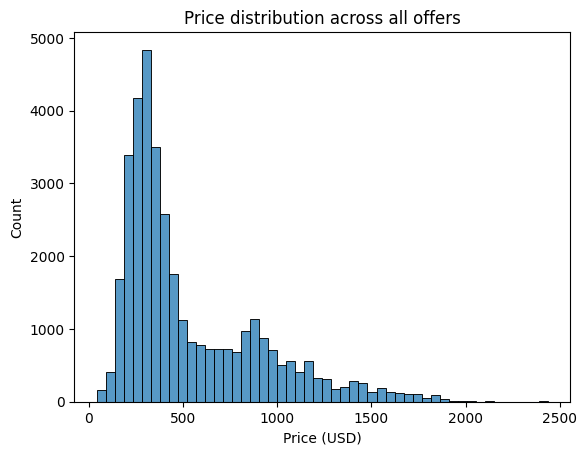

In [42]:
sns.histplot(data=df, x="price", bins=50)
plt.title("Price distribution across all offers")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

Price vs Lead Time

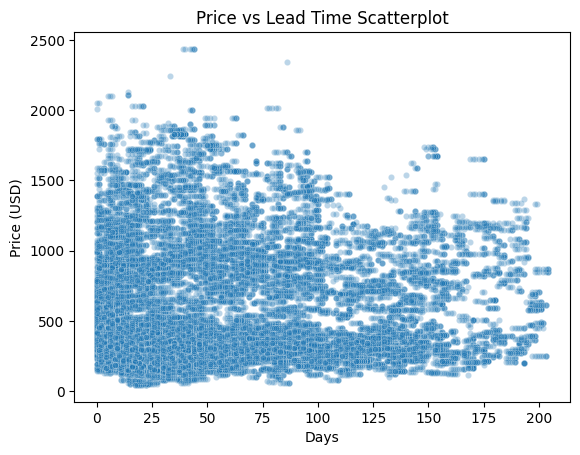

In [43]:
sns.scatterplot(data=df, x="lead_time_days", y="price",s=20, alpha=0.3)
plt.title("Price vs Lead Time Scatterplot")
plt.ylabel("Price (USD)")
plt.xlabel("Days")
plt.show()

Text(0.5, 1.0, 'price')

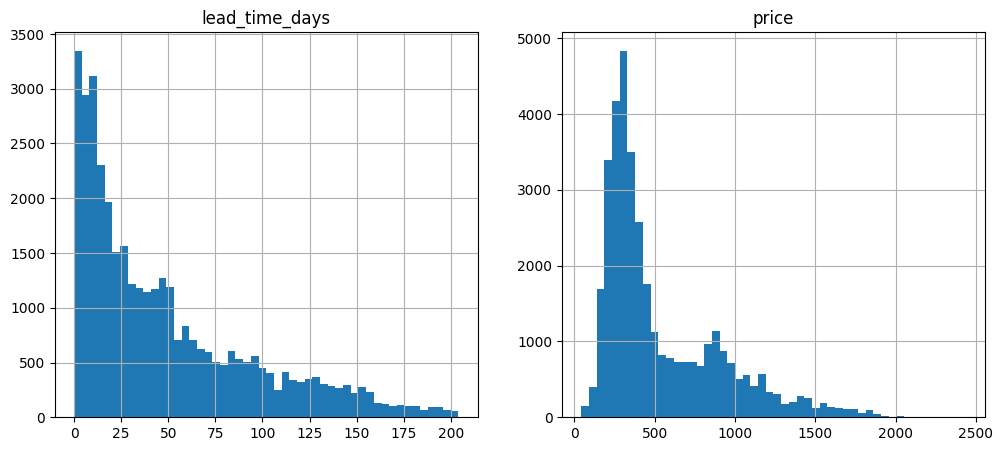

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['lead_time_days'].hist(bins=50, ax=axes[0])
axes[0].set_title('lead_time_days')

df['price'].hist(bins=50, ax=axes[1])
axes[1].set_title('price')

Price vs Is International

<Axes: xlabel='price', ylabel='Count'>

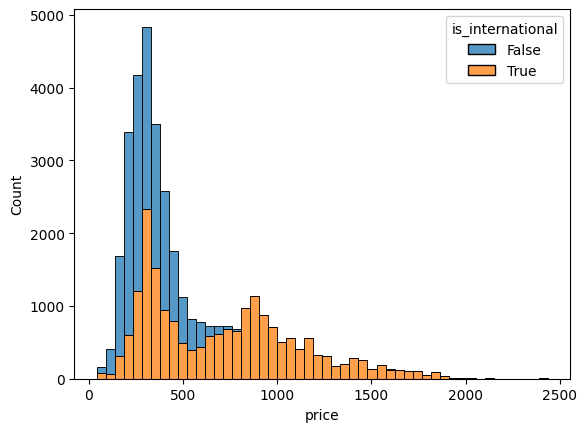

In [45]:
airports_df = pd.read_sql("SELECT iata, country FROM airports", conn)
df = df.merge(airports_df.rename(columns={"iata": "origin_airport", "country": "origin_country"}),
              on="origin_airport", how="left")
df = df.merge(airports_df.rename(columns={"iata": "destination_airport", "country": "destination_country"}),
              on="destination_airport", how="left")

df["is_international"] = df["origin_country"] != df["destination_country"]
sns.histplot(data=df, x="price", hue="is_international", bins=50, multiple="stack")



Price vs Distance

<Axes: xlabel='distance_km', ylabel='price'>

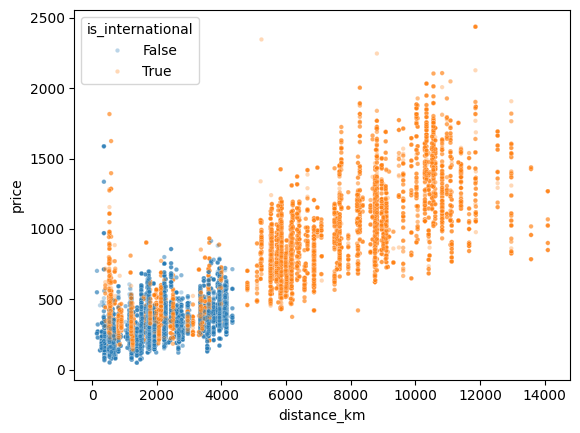

In [46]:
#Implementation of scatterplot Price vs Distance here

from math import radians, sin, cos, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * R * asin(sqrt(a))


airports_df = pd.read_sql("SELECT iata, latitude, longitude FROM airports", conn)
df = df.merge(airports_df.rename(columns={"iata": "origin_airport", "latitude": "origin_latitude", "longitude": "origin_longitude"}),
              on="origin_airport", how="left")
df = df.merge(airports_df.rename(columns={"iata": "destination_airport", "latitude": "destination_latitude", "longitude": "destination_longitude"}),
              on="destination_airport", how="left")

df["distance_km"] = df.apply(
    lambda row: haversine_km(row["origin_latitude"], row["origin_longitude"], 
                             row["destination_latitude"], row["destination_longitude"]), axis=1
)

sns.scatterplot(data=df, x="distance_km", y="price",
                hue="is_international", s=10, alpha=0.3)


#Notes: Have to compute the distance first, as it is not a column in the DB. 

Price vs Lead Time (Separated)

<Axes: title={'center': 'Long'}, xlabel='lead_time_days', ylabel='price'>

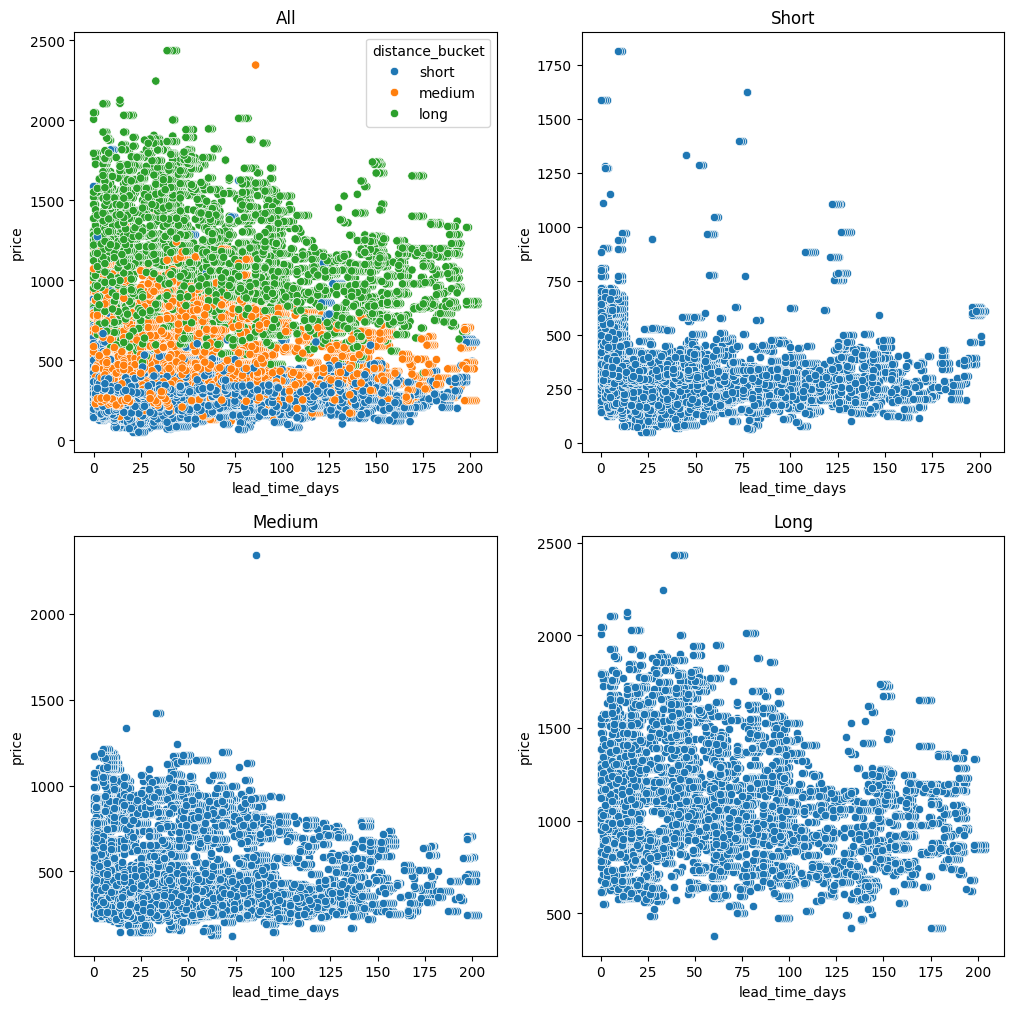

In [56]:

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
df["distance_bucket"] = pd.cut(df["distance_km"], bins=[0, 2000, 6000, 15000], labels=["short","medium","long"])
df_short = df[df["distance_bucket"] == "short"]
df_medium = df[df["distance_bucket"] == "medium"]
df_long = df[df["distance_bucket"] == "long"]
sns.scatterplot(data=df, x="lead_time_days", y="price", hue="distance_bucket", ax=axes[0, 0])
axes[0,0].set_title("All")
axes[0,1].set_title("Short")
axes[1,0].set_title("Medium")
axes[1,1].set_title("Long")

sns.scatterplot(data=df_short, x="lead_time_days", y="price", ax=axes[0, 1])
sns.scatterplot(data=df_medium, x="lead_time_days", y="price", ax=axes[1, 0])
sns.scatterplot(data=df_long, x="lead_time_days", y="price", ax=axes[1, 1])


Median price vs lead time (testing the visual trend)

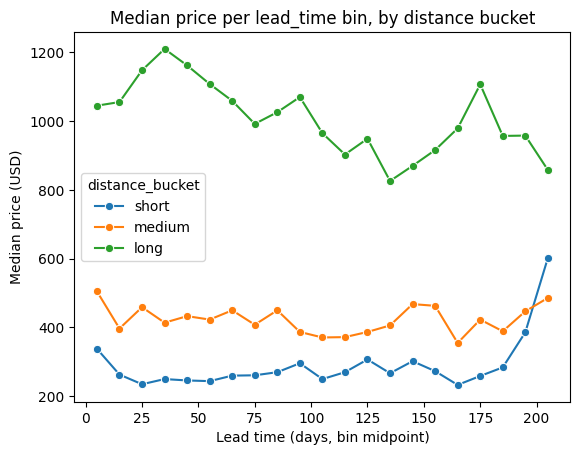

In [ ]:

df["lead_bin"] = pd.cut(df["lead_time_days"], bins=range(0, 220, 10))

def midpoint(interval):
    if pd.isnull(interval):
        return None
    return interval.mid

df["lead_bin_mid"] = df["lead_bin"].apply(midpoint)

#grouping columns
groups = df.groupby(["lead_bin_mid", "distance_bucket"], observed=True)
price_medians = groups["price"].median()
medians = price_medians.reset_index()

sns.lineplot(
    data=medians,
    x="lead_bin_mid",
    y="price",
    hue="distance_bucket",
    marker="o",
)
plt.title("Median price per lead_time bin, by distance bucket")
plt.xlabel("Lead time (days, bin midpoint)")
plt.ylabel("Median price (USD)")
plt.show()